# Wind Power Forecasting – Execution Notebook (corrected)
This notebook runs the modelling pipeline for **h=1,2,3** hours ahead using the **aligned dataset**.

In [1]:
import numpy as np
import pandas as pd

from data_prep import WindDataManager
from models import (
    rmse, mae, lb_pvalue,
    KalmanARXWhite,
    KalmanARXRegimeARNoise,
    RegimeSpec,
)
from plotting import residual_diagnostics, plot_param_traces


In [2]:
# -----------------------------
# 1) Data preparation
# -----------------------------
data_path = r"assignment4\data\cex4WindDataInterpolated.csv"  # <- change me

data_mgr = WindDataManager(
    data_path=data_path,
    time_col="t",
    target_col="p",
    toy_col="toy",
    max_lag=140,
    train_frac=0.7,
    val_frac_within_train=0.2,
)

df = data_mgr.load_and_prepare()
split = data_mgr.split()

print("df:", df.shape)
print("train:", split.train_df.shape, "test:", split.test_df.shape)
print("knots (Ws1 quantiles):", data_mgr.knots)
print("p_max:", data_mgr.p_max)


df: (35443, 184)
train: (24810, 184) test: (10633, 184)
knots (Ws1 quantiles): [ 4.8  7.9 11.5]
p_max: 20.3


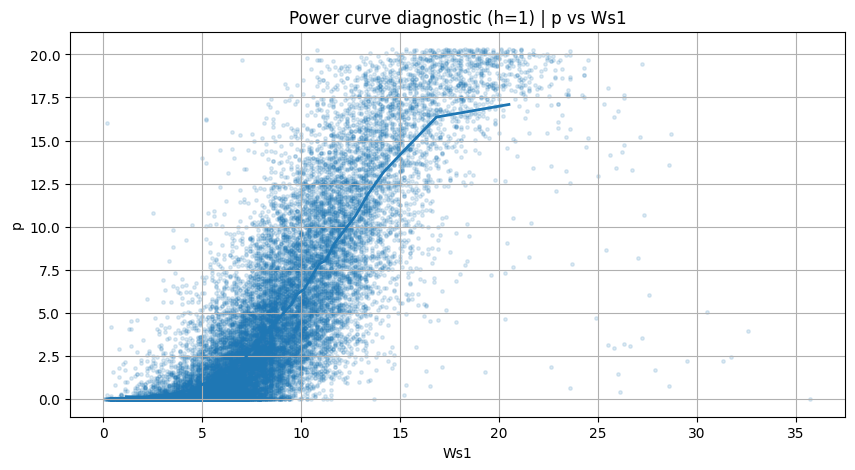

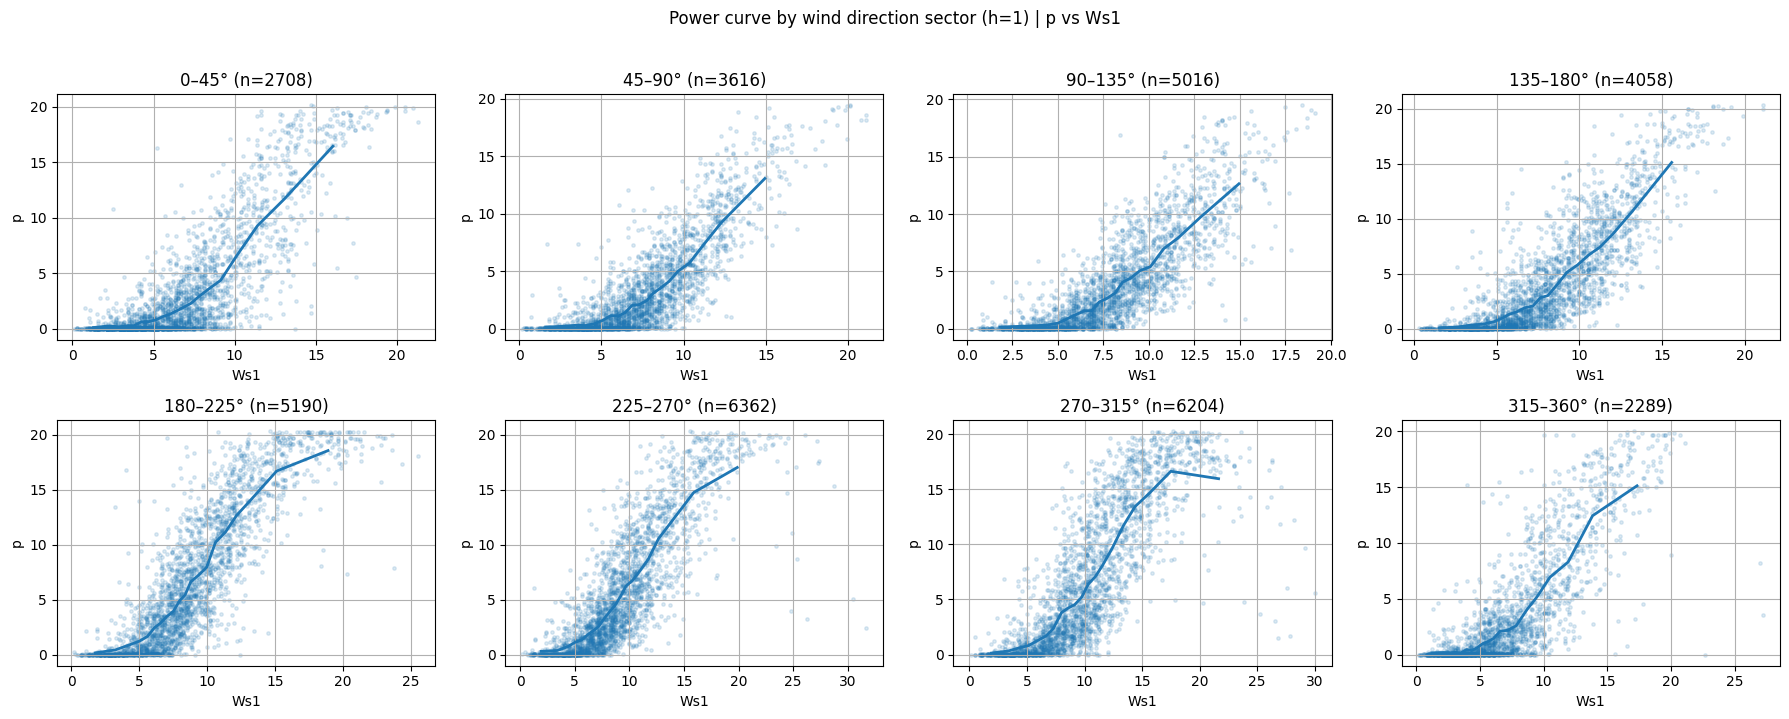

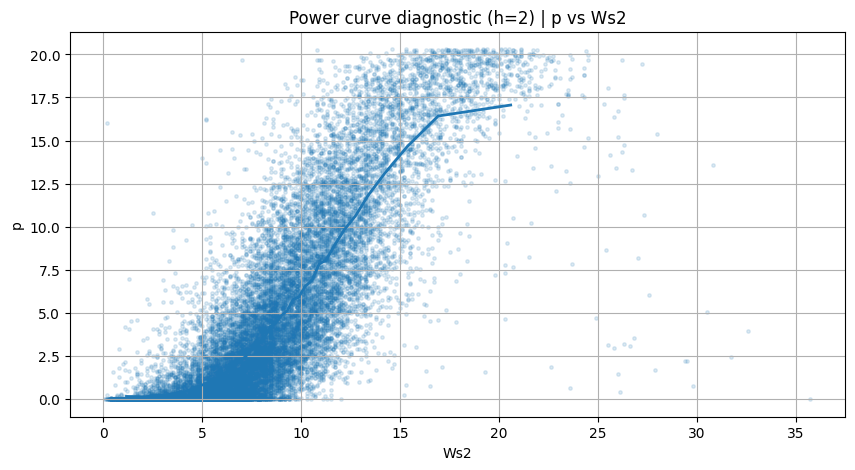

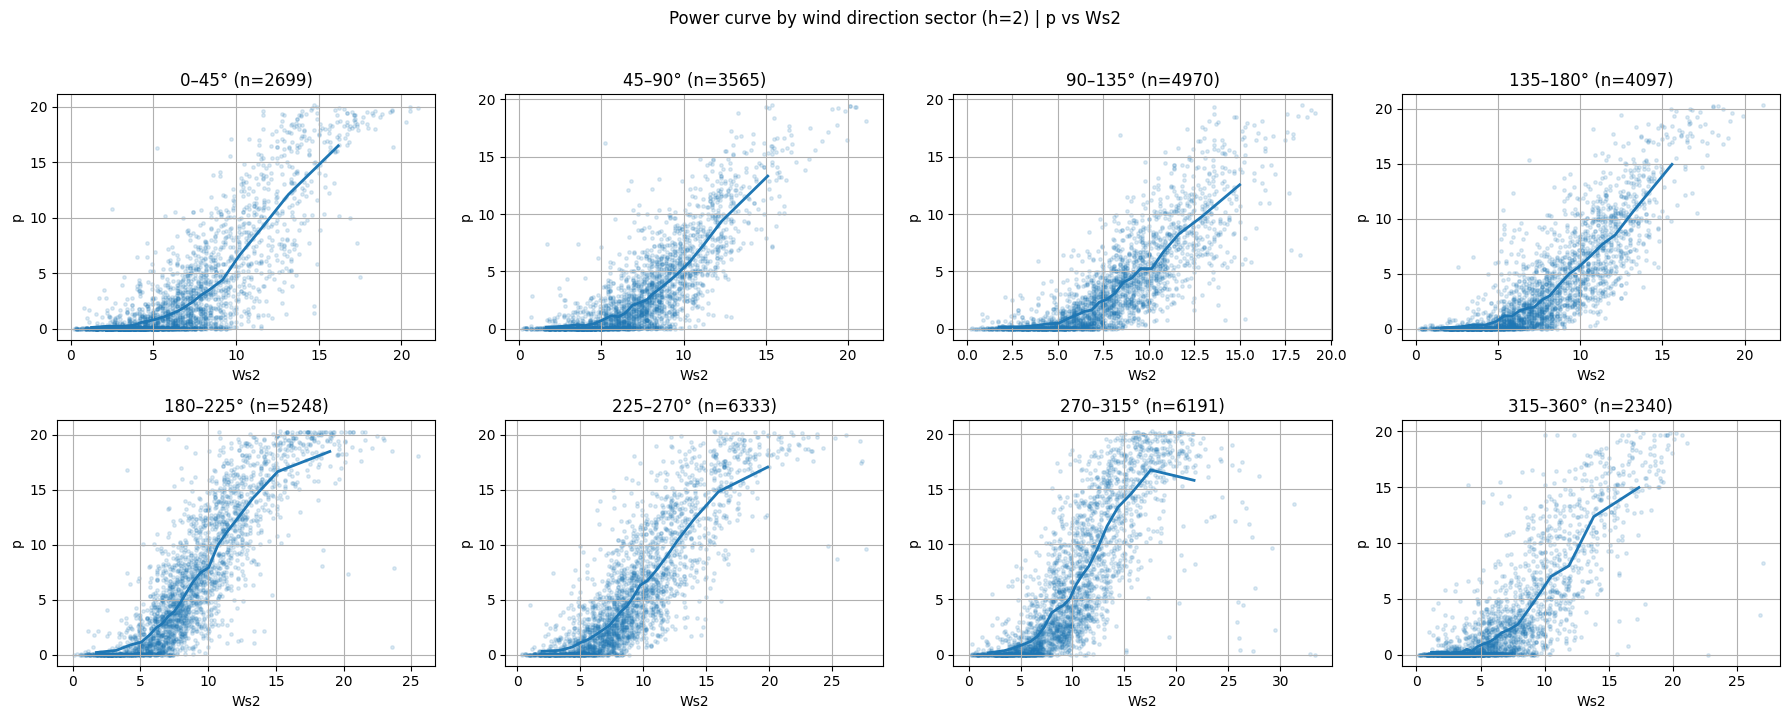

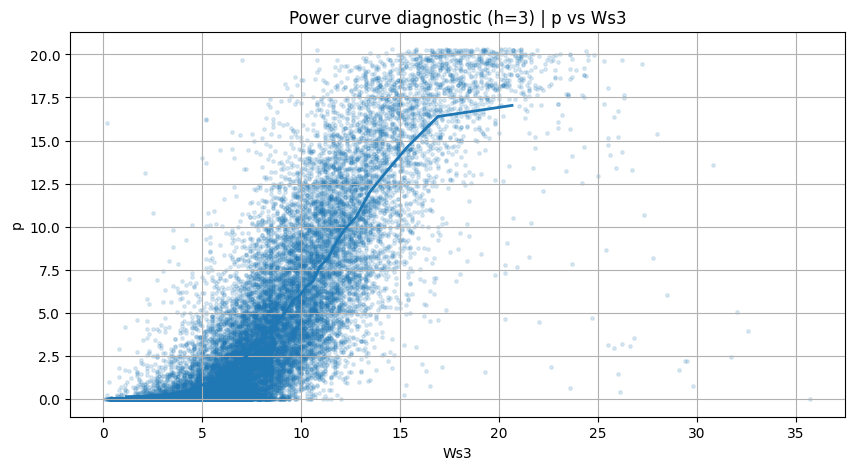

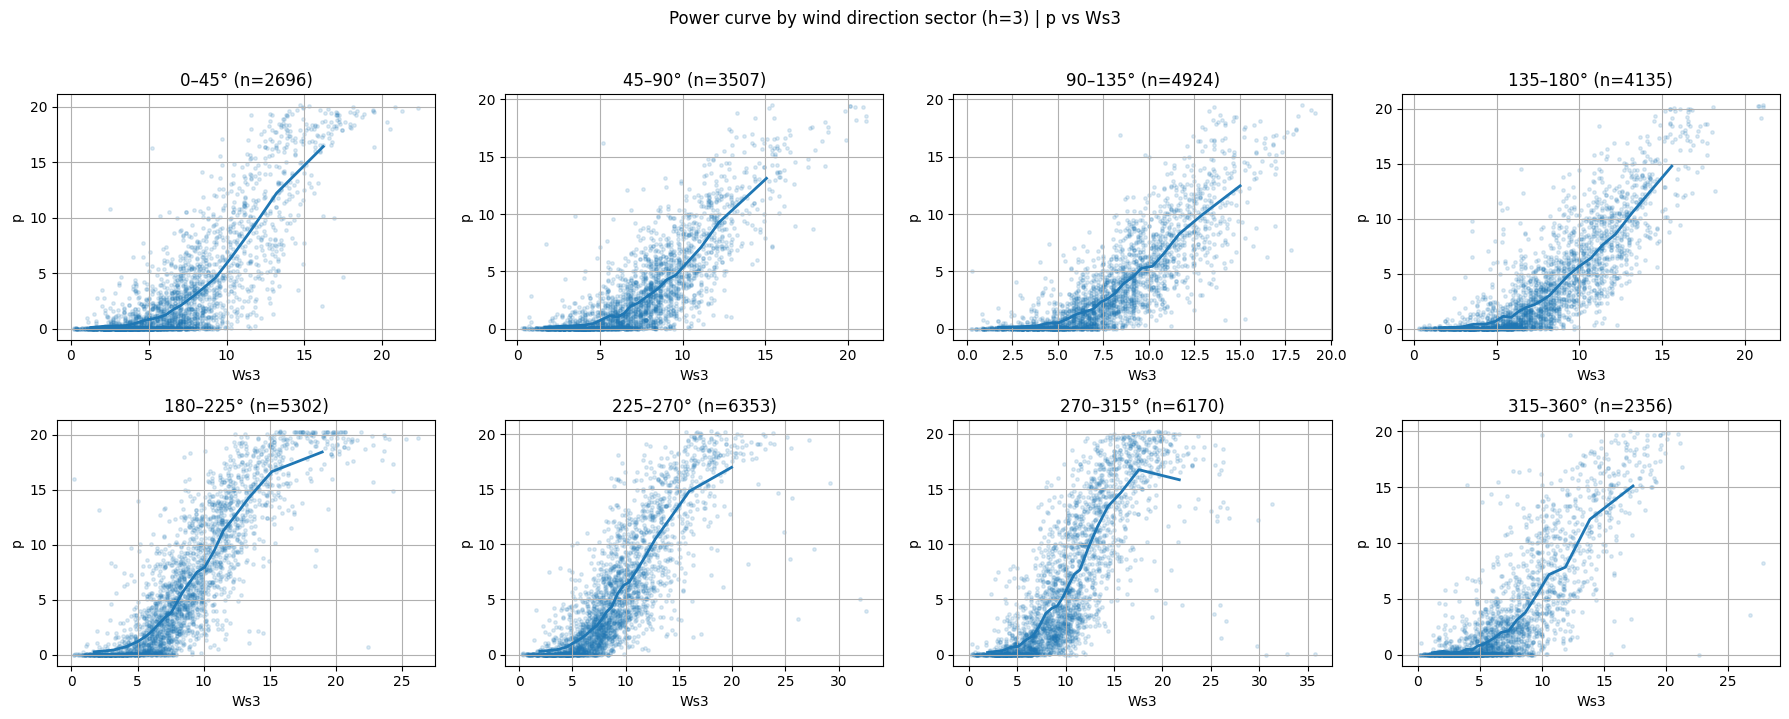

In [3]:
from plotting import plot_power_curve_diagnostics

plot_power_curve_diagnostics(df, h=1)
plot_power_curve_diagnostics(df, h=2)
plot_power_curve_diagnostics(df, h=3)

In [4]:
# -----------------------------
# 2) Runner
# -----------------------------
def run_models_on_horizon(
    h: int,
    data_mgr: WindDataManager,
    split,
    models: dict,
    lb_lag: int = 48,
    trace_top_k: int = 10,
    do_plots: bool = True,
):
    # Build and cache X/y ONCE per horizon and split parts (train_df, train_in, val_in, test_df)
    Xy = data_mgr.get_cached_Xy(h=h, split=split)

    rows, outs = [], {}

    for name, model in models.items():
        out = model.fit_predict(h=h, data_mgr=data_mgr, split=split, Xy=Xy)
        outs[name] = out

        resid = np.asarray(out["resid"], dtype=float)
        rb = out.get("rb", None)

        if rb is not None and getattr(rb, "std_innov", None) is not None:
            lb_series = np.asarray(rb.std_innov, dtype=float)
            lb_kind = "std_innov"
        else:
            lb_series = resid
            lb_kind = "resid"

        rows.append(
            {
                "h": h,
                "model": name,
                "RMSE": rmse(out["y"], out["pred"]),
                "MAE": mae(out["y"], out["pred"]),
                f"LB_pvalue_lag{lb_lag}({lb_kind})": lb_pvalue(lb_series, lag=lb_lag),
            }
        )

        if do_plots:
            if "beta_trace" in out and "names" in out:
                plot_param_traces(
                    out["beta_trace"],
                    out["names"],
                    top_k=trace_top_k,
                    title=f"{name} | h={h} | beta traces",
                )
            residual_diagnostics(out, title=f"{name} | h={h}", lb_lag=lb_lag)

    results = pd.DataFrame(rows).sort_values(["h", "RMSE"]).reset_index(drop=True)
    return results, outs


In [5]:
from models import TARObsVarSpec, KalmanARXWhiteTARObsVar

# 3.1 Baseline KF ARX (white obs noise) — tuned internally on (train_in -> val_in)
kf_white = KalmanARXWhite(
    q_grid=[1e-6, 1e-5, 1e-4, 1e-3],
    r_scale_grid=[0.25, 0.5, 1.0, 2.0, 4.0],
    lb_lag=48,
    alpha_lb_penalty=0.15,
)

# 3.2 KF ARX with TAR observation variance (time-varying R_t)
# Try TAR driven by level (Ws) and ramp magnitude (|dWs|).
kf_tar_ws = KalmanARXWhiteTARObsVar(
    tar_spec=TARObsVarSpec(driver="Ws", c_grid=None),  # c_grid None => quantile grid on train_in
    q_grid=[1e-6, 1e-5, 1e-4, 1e-3],
    r_low_scale_grid=[0.25, 0.5, 1.0],
    r_high_scale_grid=[1.0, 2.0, 4.0],
    lb_lag=48,
    alpha_lb_penalty=0.15,
)

kf_tar_absdws = KalmanARXWhiteTARObsVar(
    tar_spec=TARObsVarSpec(driver="abs_dWs", c_grid=None),
    q_grid=[1e-6, 1e-5, 1e-4, 1e-3],
    r_low_scale_grid=[0.25, 0.5, 1.0],
    r_high_scale_grid=[1.0, 2.0, 4.0],
    lb_lag=48,
    alpha_lb_penalty=0.15,
)

# 3.3 More advanced: regime-dependent AR noise + KF for time-varying beta
# (This one currently does not "tune" parameters; treat it as a fixed, lecture-highlight model.)
regime_month = RegimeSpec(
    mode="month",
    phi_A=0.8,   # AR persistence for u_t (month mode keeps phi fixed, sigma2 varies by month proxy)
)

kf_regime_monthly = KalmanARXRegimeARNoise(
    regime_spec=regime_month,
    q_beta=1e-4,
    r_y=1e-3,
    lb_lag=48,
    alpha_lb_penalty=0.15,
)

kf_regime_directional = KalmanARXRegimeARNoise(
    regime_spec=RegimeSpec(
        mode="dir",
        phi_A=0.7,
        phi_B=0.9,
        sigma2_A=0.5,
        sigma2_B=2.0,
        cut_deg=90.0,
    ),
    q_beta=1e-4,
    r_y=1e-3,
    lb_lag=48,
    alpha_lb_penalty=0.15,
)

# Candidate model set
models = {
    "KF_white": kf_white,
    "KF_TAR_R(Ws)": kf_tar_ws,
    "KF_TAR_R(|dWs|)": kf_tar_absdws,
    "KF_regime_AR_noise_month": kf_regime_monthly,
    "KF_regime_AR_noise_dir": kf_regime_directional,
}

# 3.4 Helper to select the best model per horizon (based on validation 'score' when available)
def pick_best_model_for_horizon(results_by_name: dict) -> tuple[str, dict]:
    """
    results_by_name: mapping name -> result dict returned by model.fit_predict(...)

    Preference order:
      1) If config has 'score' (tuned models), pick min score.
      2) Otherwise fallback to min RMSE on test (still deterministic).
    """
    best_name = None
    best_key = None
    best_res = None

    for name, res in results_by_name.items():
        cfg = res.get("config", {}) or {}
        if "score" in cfg:
            key = ("score", float(cfg["score"]))
        else:
            key = ("rmse_test", rmse(res["y"], res["pred"]))

        if best_key is None or key[1] < best_key[1]:
            best_key = key
            best_name = name
            best_res = res

    return best_name, best_res



Running horizon h=1


,h,model,RMSE,MAE,LB_pvalue_lag48(std_innov)
0,1,KF_white,1.522397,0.983737,2.843841e-13
1,1,KF_TAR_R(|dWs|),1.523224,0.980885,6.963773e-11
2,1,KF_TAR_R(Ws),1.541064,0.991148,1.075788e-10
3,1,KF_regime_AR_noise_month,1.577972,1.032568,5.860947e-08
4,1,KF_regime_AR_noise_dir,1.659612,1.067550,3.355693e-10



🏁 Best model for h=1: KF_regime_AR_noise_month
Config: {'q_beta': 0.0001, 'r_y': 0.001, 'regime_spec': RegimeSpec(mode='month', cut_deg=0.0, phi_A=0.8, phi_B=0.2, sigma2_A=1.0, sigma2_B=4.0), 'phi_summary': {'min': 0.8, 'max': 0.8}, 'sigma2_summary': {'min': 1.5410536363776473, 'max': 4.630438048164592}}


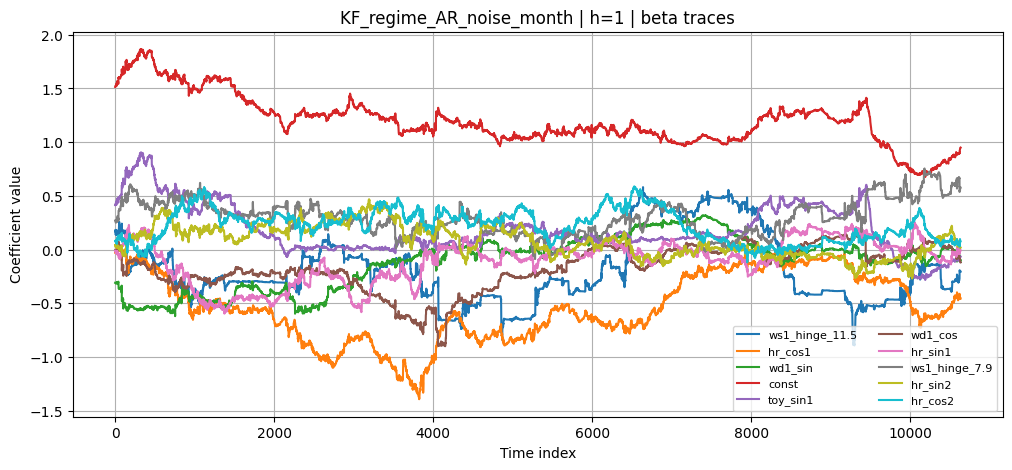

KF_regime_AR_noise_month | h=1 | LB(48) on std_innov: p=5.861e-08


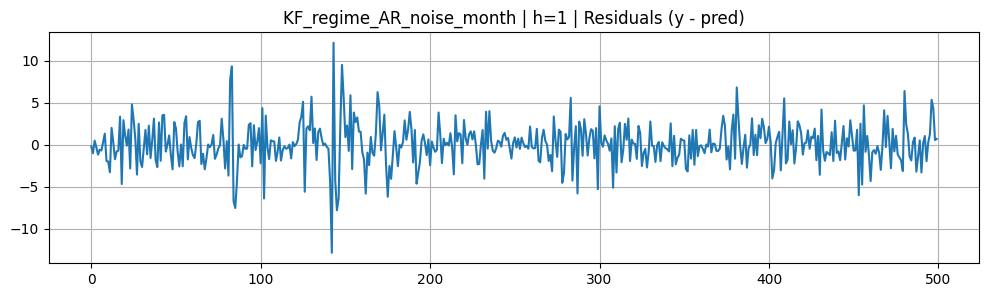

<Figure size 800x400 with 0 Axes>

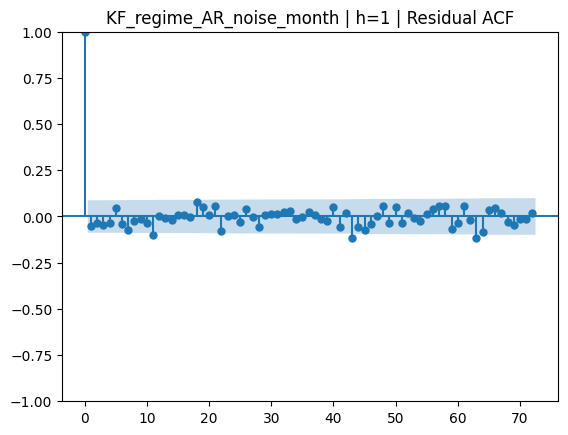

<Figure size 800x400 with 0 Axes>

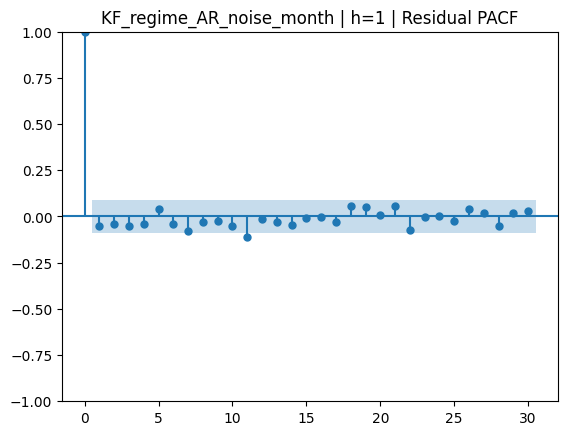

<Figure size 800x400 with 0 Axes>

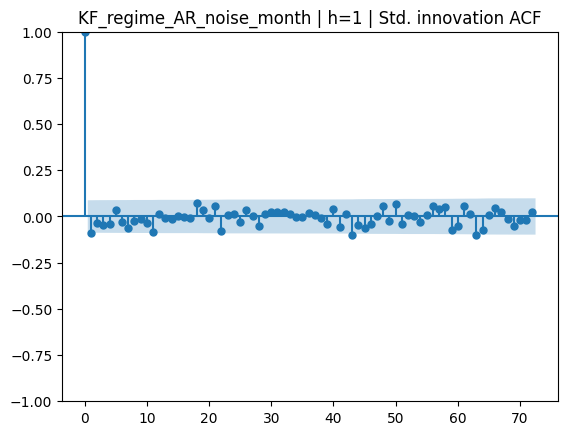

,h,model,RMSE,MAE,LB_pvalue_lag48(std_innov)
0,1,KF_regime_AR_noise_month,1.577972,1.032568,5.860947e-08



Running horizon h=2


,h,model,RMSE,MAE,LB_pvalue_lag48(std_innov)
0,2,KF_regime_AR_noise_month,1.620237,1.063225,9.202465e-25
1,2,KF_regime_AR_noise_dir,1.711668,1.102528,4.251938e-17
2,2,KF_TAR_R(|dWs|),1.915590,1.270298,0.000000e+00
3,2,KF_white,1.925361,1.274461,0.000000e+00
4,2,KF_TAR_R(Ws),1.931376,1.279063,0.000000e+00



🏁 Best model for h=2: KF_regime_AR_noise_month
Config: {'q_beta': 0.0001, 'r_y': 0.001, 'regime_spec': RegimeSpec(mode='month', cut_deg=0.0, phi_A=0.8, phi_B=0.2, sigma2_A=1.0, sigma2_B=4.0), 'phi_summary': {'min': 0.8, 'max': 0.8}, 'sigma2_summary': {'min': 1.5410536363776473, 'max': 4.630438048164592}}


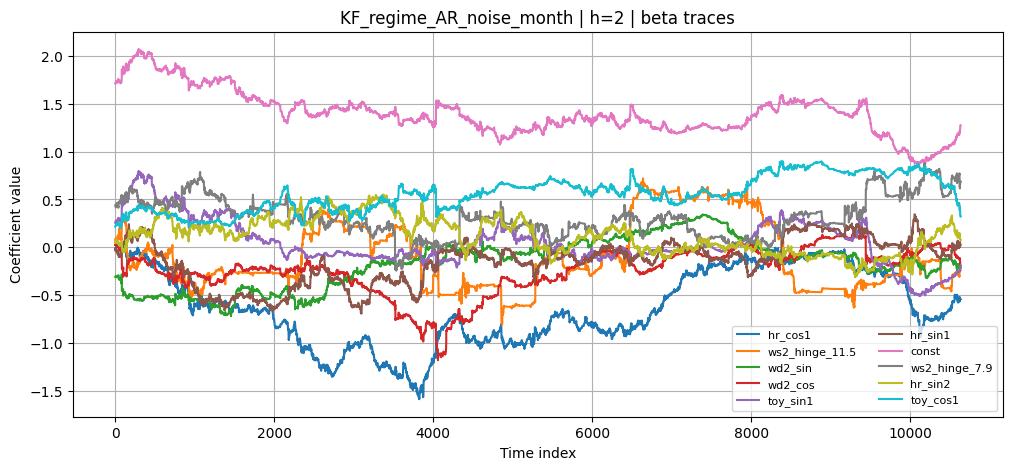

KF_regime_AR_noise_month | h=2 | LB(48) on std_innov: p=9.202e-25


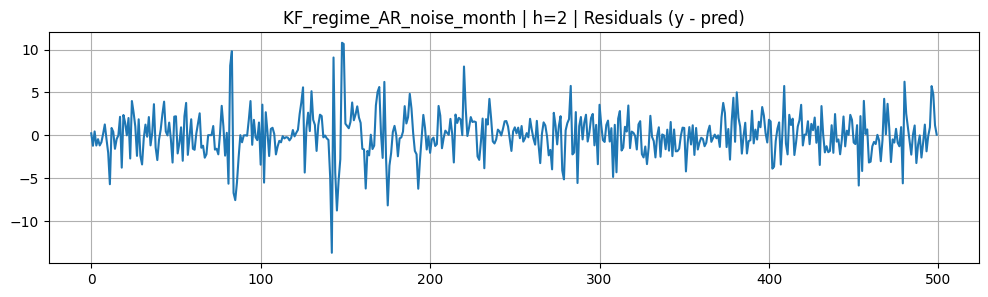

<Figure size 800x400 with 0 Axes>

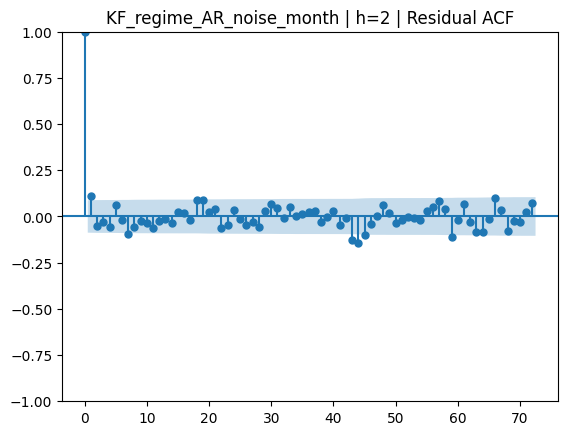

<Figure size 800x400 with 0 Axes>

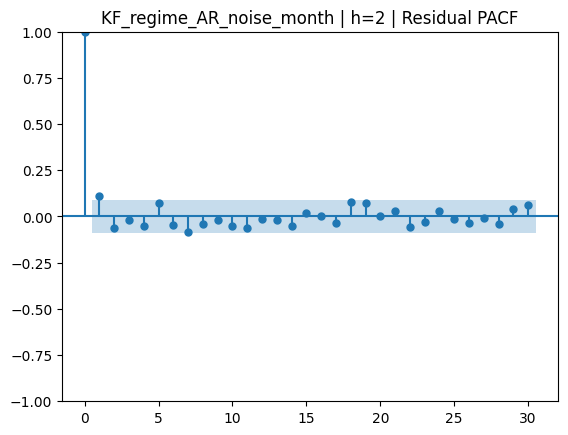

<Figure size 800x400 with 0 Axes>

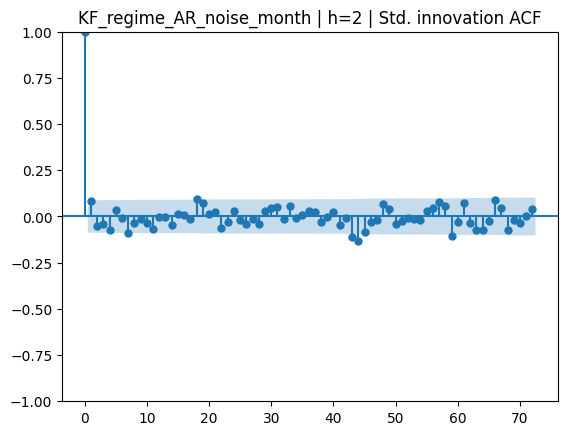

,h,model,RMSE,MAE,LB_pvalue_lag48(std_innov)
0,2,KF_regime_AR_noise_month,1.620237,1.063225,9.202465e-25



Running horizon h=3


,h,model,RMSE,MAE,LB_pvalue_lag48(std_innov)
0,3,KF_regime_AR_noise_month,1.615934,1.059352,3.427513e-26
1,3,KF_regime_AR_noise_dir,1.700955,1.095434,3.898968e-19
2,3,KF_TAR_R(|dWs|),1.958820,1.314284,0.000000e+00
3,3,KF_white,1.964486,1.314862,0.000000e+00
4,3,KF_TAR_R(Ws),2.024374,1.348804,0.000000e+00



🏁 Best model for h=3: KF_regime_AR_noise_month
Config: {'q_beta': 0.0001, 'r_y': 0.001, 'regime_spec': RegimeSpec(mode='month', cut_deg=0.0, phi_A=0.8, phi_B=0.2, sigma2_A=1.0, sigma2_B=4.0), 'phi_summary': {'min': 0.8, 'max': 0.8}, 'sigma2_summary': {'min': 1.5410536363776473, 'max': 4.630438048164592}}


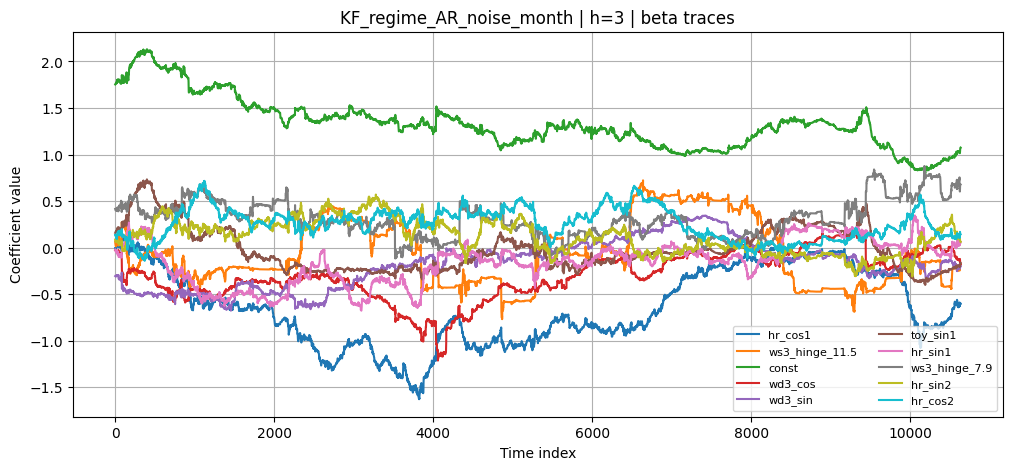

KF_regime_AR_noise_month | h=3 | LB(48) on std_innov: p=3.428e-26


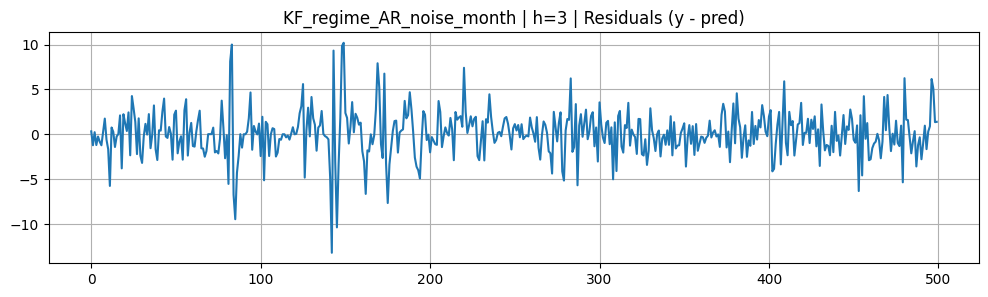

<Figure size 800x400 with 0 Axes>

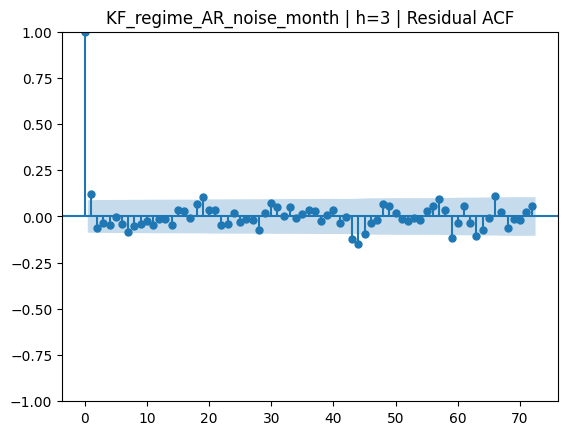

<Figure size 800x400 with 0 Axes>

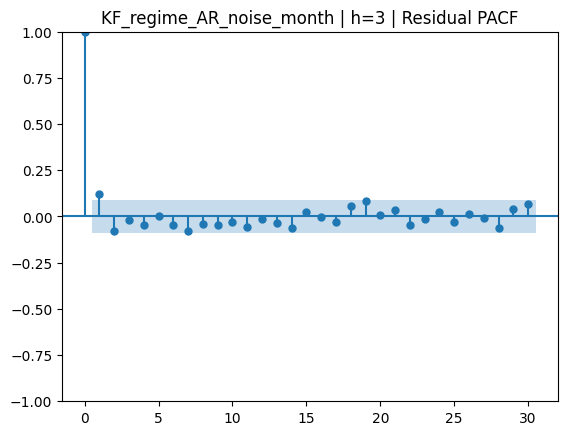

<Figure size 800x400 with 0 Axes>

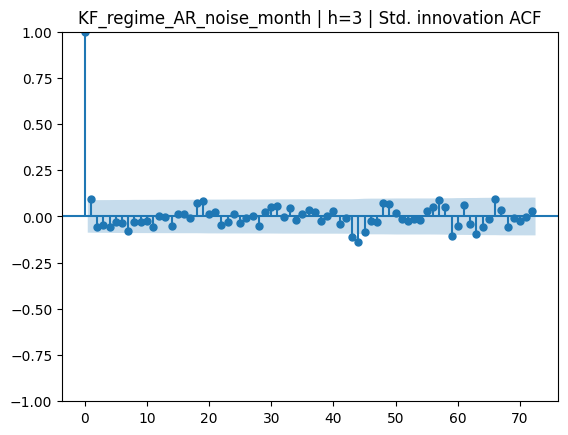

,h,model,RMSE,MAE,LB_pvalue_lag48(std_innov)
0,3,KF_regime_AR_noise_month,1.615934,1.059352,3.427513e-26



Summary (best marked, sorted by horizon):


,h,model,RMSE,MAE,LB_pvalue_lag48(std_innov),is_best
0,1,KF_regime_AR_noise_month,1.577972,1.032568,5.860947e-08,True
1,1,KF_white,1.522397,0.983737,2.843841e-13,False
2,1,KF_TAR_R(|dWs|),1.523224,0.980885,6.963773e-11,False
3,1,KF_TAR_R(Ws),1.541064,0.991148,1.075788e-10,False
4,1,KF_regime_AR_noise_dir,1.659612,1.067550,3.355693e-10,False
5,2,KF_regime_AR_noise_month,1.620237,1.063225,9.202465e-25,True
6,2,KF_regime_AR_noise_dir,1.711668,1.102528,4.251938e-17,False
7,2,KF_TAR_R(|dWs|),1.915590,1.270298,0.000000e+00,False
8,2,KF_white,1.925361,1.274461,0.000000e+00,False
9,2,KF_TAR_R(Ws),1.931376,1.279063,0.000000e+00,False



Best model per horizon:


,h,model,RMSE,MAE,LB_pvalue_lag48(std_innov),is_best
0,1,KF_regime_AR_noise_month,1.577972,1.032568,5.860947e-08,True
1,2,KF_regime_AR_noise_month,1.620237,1.063225,9.202465e-25,True
2,3,KF_regime_AR_noise_month,1.615934,1.059352,3.427513e-26,True


In [7]:
# -----------------------------
# 4) Run experiments – run ALL candidates, then pick BEST per horizon (h=1,2,3)
# -----------------------------
all_rows = []
best_by_h = {}

for h in (1, 2, 3):
    print("\n==============================")
    print(f"Running horizon h={h}")
    print("==============================")

    # 4.1 Run every model for this horizon
    res_h, outs_h = run_models_on_horizon(
        h=h,
        data_mgr=data_mgr,
        split=split,
        models=models,          # <-- run all candidates (dict name -> model)
        lb_lag=48,
        trace_top_k=10,
        do_plots=False,         # <-- we'll plot only the winner (cleaner)
    )

    # Show the comparison table for this horizon
    display(res_h.sort_values("RMSE").reset_index(drop=True))

    # 4.2 Pick best model for this horizon
    # outs_h should be: name -> model output dict returned by fit_predict
    best_name, best_out = pick_best_model_for_horizon(outs_h)
    best_by_h[h] = {"name": best_name, "out": best_out}

    print(f"\n🏁 Best model for h={h}: {best_name}")
    cfg = (best_out.get("config", {}) or {})
    if cfg:
        print("Config:", cfg)

    # 4.3 Plot diagnostics ONLY for the winner (uses your existing plotting helpers)
    # (Assumes your run_models_on_horizon / plotting.py already has functions to plot residual ACF, traces, etc.)
    # If run_models_on_horizon already does the plotting, you can call it again with do_plots=True for only that model.
    _res_best, _outs_best = run_models_on_horizon(
        h=h,
        data_mgr=data_mgr,
        split=split,
        models={best_name: models[best_name]},  # run only the winner to produce plots
        lb_lag=48,
        trace_top_k=10,
        do_plots=True,
    )
    display(_res_best)

    # Collect rows for global summary
    res_h = res_h.copy()
    res_h["is_best"] = res_h["model"].eq(best_name)
    all_rows.append(res_h)

summary = (
    pd.concat(all_rows, ignore_index=True)
      .sort_values(["h", "is_best", "RMSE"], ascending=[True, False, True])
      .reset_index(drop=True)
)

print("\nSummary (best marked, sorted by horizon):")
display(summary)

# Optional: a compact "best only" table
best_only = summary[summary["is_best"]].sort_values("h").reset_index(drop=True)
print("\nBest model per horizon:")
display(best_only)
